In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
import time

# Deutsch's Algorithm: Standard Qiskit Implementation

This notebook contains the standard matrix-based implementation of Deutsch's algorithm using IBM's `qiskit` library. 

### 1. Quantum Oracles
We define four possible functions $f: \{0, 1\} \rightarrow \{0, 1\}$ (two constant and two balanced) as quantum circuits.

In [3]:
def deutsch_oracle(case):
    """
    Constructs a 2-qubit quantum oracle for Deutsch's algorithm.
    Qubit 0 is the data (control) qubit, Qubit 1 is the target qubit.
    """
    oracle = QuantumCircuit(2, name=f"Oracle: {case}")
    
    if case == "constant0":
        # f(x) = 0: Does nothing
        pass
        
    elif case == "constant1":
        # f(x) = 1: Flips the target qubit regardless of the input
        oracle.x(1)
        
    elif case == "balanced_identity":
        # f(x) = x: Flips the target if the input is 1 (Standard CNOT)
        oracle.cx(0, 1)
        
    elif case == "balanced_not":
        # f(x) = NOT x: Flips the target if the input is 0
        oracle.x(0)       # Flip control
        oracle.cx(0, 1)   # Apply CNOT
        oracle.x(0)       # Flip control back to original state
        
    return oracle

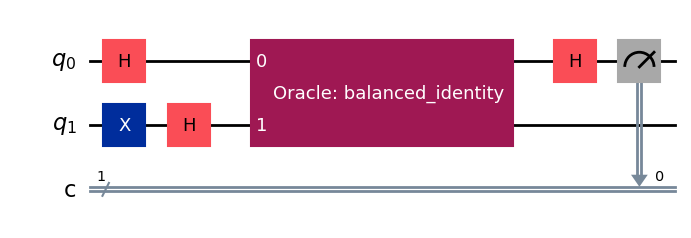

In [ ]:
def deutsch_algorithm(case):
    """
    Constructs the full quantum circuit for Deutsch's algorithm.
    1. Prepares the data qubit in |+> and target qubit in |->.
    2. Applies the selected oracle.
    3. Performs final Hadamard transformation on the data qubit.
    4. Measures the data qubit.
    """
    # Create a circuit with 2 quantum bits and 1 classical bit for measurement
    qc = QuantumCircuit(2, 1)
    
    # Step 1: Initialize inputs into superposition states
    qc.h(0)     # Data qubit to |+>
    qc.x(1)     # Target qubit to |1>
    qc.h(1)     # Target qubit to |->
    
    # Step 2: Query the chosen oracle
    qc.append(deutsch_oracle(case), [0, 1])
    
    # Step 3: Interference on the data qubit
    qc.h(0)
    
    # Step 4: Measurement of the data qubit
    qc.measure(0, 0)
    
    return qc

# --- Circuit Visualization ---
example_circuit = deutsch_algorithm('balanced_identity')
example_circuit.draw('mpl')

In [ ]:
# --- Execution & Simulation ---

# We use the Aer simulator to run our quantum circuits
simulator = Aer.get_backend('aer_simulator')

print("=== Qiskit Simulation Results ===")

# List of all four oracles to test
cases = [
    "constant0", 
    "constant1", 
    "balanced_identity", 
    "balanced_not"
]

for case in cases:
    # 1. Build the circuit
    qc = deutsch_algorithm(case)
    
    # 2. Transpile the circuit for the simulator
    tqc = transpile(qc, simulator)
    
    # 3. Timing the simulation execution
    start = time.perf_counter()
    job = simulator.run(tqc, shots=1024)
    result = job.result()
    end = time.perf_counter()
    
    # 4. Extract and print results
    counts = result.get_counts()
    print(f"Oracle [{case}]:")
    print(f" -> Measured states: {counts}")
    
    # 5. Evaluate the conclusion
    if '0' in counts and counts['0'] == 1024:
        print(" -> Conclusion: Function is CONSTANT")
    elif '1' in counts and counts['1'] == 1024:
        print(" -> Conclusion: Function is BALANCED")
        
    print(f"⏱️ Execution time: {end - start:.6f} seconds\n")

=== Qiskit Simulation Results ===
Oracle [constant0]:
 -> Measured states: {'0': 1024}
 -> Conclusion: Function is CONSTANT (Measured |0> with 100% certainty)
⏱️ Execution time: 0.001709 seconds

Oracle [constant1]:
 -> Measured states: {'0': 1024}
 -> Conclusion: Function is CONSTANT (Measured |0> with 100% certainty)
⏱️ Execution time: 0.000915 seconds

Oracle [balanced_identity]:
 -> Measured states: {'1': 1024}
 -> Conclusion: Function is BALANCED (Measured |1> with 100% certainty)
⏱️ Execution time: 0.003291 seconds

Oracle [balanced_not]:
 -> Measured states: {'1': 1024}
 -> Conclusion: Function is BALANCED (Measured |1> with 100% certainty)
⏱️ Execution time: 0.000817 seconds



## 3. Execution on Real Quantum Hardware (IBM Quantum)

To demonstrate the difference between ideal mathematical simulation and physical reality (quantum noise, decoherence), we will execute the algorithm on a real superconducting quantum processor.

**Note:** You need an active IBM Quantum account and API token to run this section.

In [17]:
# --- Step 1: Authentication and Service Setup ---
from qiskit_ibm_runtime import QiskitRuntimeService

print("=== Initializing IBM Quantum Service ===")

# Insert your personal API token from https://quantum.ibm.com/
api_token = "VLJmDg7aQWD68T6VPBNuZPlS3X16xxl1-BD5n9kAFqhW"

# Connect to the cloud service
service = QiskitRuntimeService(channel="ibm_cloud", token=api_token)
print("-> Service initialized successfully.")

qiskit_runtime_service._discover_account:WARNING:2026-06-02 21:22:14,174: Loading account with the given token. A saved account will not be used.


=== Initializing IBM Quantum Service ===


qiskit_runtime_service.__init__:WARNING:2026-06-02 21:22:16,536: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: Research_VUT. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


-> Service initialized successfully.


Since real quantum computers have varying queue lengths and maintenance windows, we dynamically query the IBM service to find the least busy operational system that has at least 2 qubits.

In [18]:

print("Looking for the least busy real quantum computer (min. 2 qubits)...")

# Filter for real hardware only (simulator=False)
real_backend = service.least_busy(simulator=False, operational=True, min_num_qubits=2)

print(f"-> Selected hardware backend: {real_backend.name}")

Looking for the least busy real quantum computer (min. 2 qubits)...


qiskit_runtime_service.backends:WARNING:2026-06-02 21:22:18,888: Loading instance: Research_VUT, plan: premium
qiskit_runtime_service.backends:WARNING:2026-06-02 21:22:21,983: Using instance: Research_VUT, plan: premium


-> Selected hardware backend: ibm_pittsburgh


We prepare our quantum circuit and **transpile** it. Transpilation is a critical step for real hardware: it maps our abstract logic gates into the physical topology and native microwave pulses specific to the selected quantum chip. After transpilation, the job is sent to the queue.

In [21]:
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

print("=== Preparing and transpiling circuits for ALL 4 Oracles ===")

cases = ["constant0", "constant1", "balanced_identity", "balanced_not"]
tqc_list = []

for case in cases:
    qc = deutsch_algorithm(case)
    tqc = transpile(qc, target=real_backend.target)
    tqc_list.append(tqc)

print(f"-> Opening dedicated Session on {real_backend.name}...")

with Session(backend=real_backend) as session:
    sampler = Sampler(mode=session)
    
    start_time = time.perf_counter()
    
    # 2. Send all circuits together as a single batch list
    print("-> Sending batch job to the queue...")
    job_real = sampler.run(tqc_list, shots=1024)
    
    print(f"-> Batch job successfully sent! (ID: {job_real.job_id()})")
    print("-> Real-time status monitoring:")
    
    last_status = None
    while not job_real.in_final_state():
        current_status = job_real.status()
        if current_status != last_status:
            print(f"   [IBM Status]: {current_status}")
            last_status = current_status
        time.sleep(3)
        
    # Retrieve the result object once the job is finished
    result_real = job_real.result()
    end_time = time.perf_counter()

print(f"\n-> All jobs completed in {end_time - start_time:.2f} seconds!")

=== Preparing and transpiling circuits for ALL 4 Oracles ===
-> Opening dedicated Session on ibm_pittsburgh...
-> Sending batch job to the queue...
-> Batch job successfully sent! (ID: d8fj14bo3njc73f0cmcg)
-> Real-time status monitoring:
   [IBM Status]: QUEUED
   [IBM Status]: RUNNING

-> All jobs completed in 484.62 seconds!


In [22]:
# --- Step 4: Results Extraction and Evaluation for All Oracles ---
print("=== REAL HARDWARE RESULTS FOR ALL ORACLES ===")

for i, case in enumerate(cases):
    pub_result = result_real[i]
    
    # Safely extract counts from the classical register
    try:
        counts_real = pub_result.data.c.get_counts()
    except AttributeError:
        register_name = list(pub_result.data.keys())[0]
        counts_real = getattr(pub_result.data, register_name).get_counts()

    print(f"\nOracle: {case}")
    print(f" -> Measured states: {counts_real}")

    # Statistical evaluation considering hardware noise
    if counts_real.get('0', 0) > 512:
        print(" -> Real Conclusion: Function is likely CONSTANT")
    elif counts_real.get('1', 0) > 512:
        print(" -> Real Conclusion: Function is likely BALANCED")

=== REAL HARDWARE RESULTS FOR ALL ORACLES ===

Oracle: constant0
 -> Measured states: {'0': 1024}
 -> Real Conclusion: Function is likely CONSTANT

Oracle: constant1
 -> Measured states: {'0': 1024}
 -> Real Conclusion: Function is likely CONSTANT

Oracle: balanced_identity
 -> Measured states: {'1': 1015, '0': 9}
 -> Real Conclusion: Function is likely BALANCED

Oracle: balanced_not
 -> Measured states: {'1': 1010, '0': 14}
 -> Real Conclusion: Function is likely BALANCED


=== Physical Circuit mapped to ibm_pittsburgh ===
Notice the use of native hardware gates (e.g., RZ, SX) instead of abstract H or X gates.


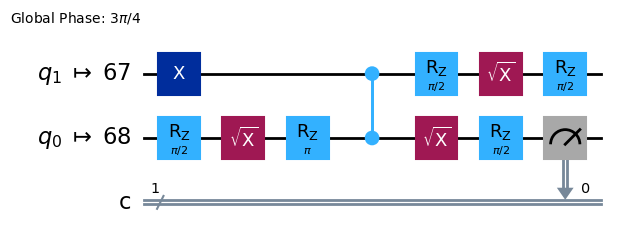

In [23]:
transpiled_circuit = tqc_list[2]

print(f"=== Physical Circuit mapped to {real_backend.name} ===")
print("Notice the use of native hardware gates (e.g., RZ, SX) instead of abstract H or X gates.")

# We use idle_wires=False to hide all the unused physical qubits on the 127-qubit chip
transpiled_circuit.draw('mpl', idle_wires=False)